# T01 OLS 最小可运行示例

完整实证链路：导包 → 数据构造与清洗 → OLS 估计 → 稳健性检查 → 可视化。

> 可直接作为新实证论文的代码模板使用。

## 0. 论文信息

- **主题**：OLS 线性回归基准示例
- **目标**：展示可直接扩展成论文实证的完整工作流
- **数据**：合成数据（后续可替换为真实样本）

## 1. 研究设计

$$y_i = \beta_0 + \beta_1 x_{1i} + \beta_2 x_{2i} + \beta_3 x_{3i} + \varepsilon_i$$

## 2. 数学理论

OLS 闭式解：$\hat{\beta} = (X'X)^{-1}X'y$

## 3. 数据加载与预处理

In [1]:
import sys, io, re as _re
from pathlib import Path

def _add_repo_to_path():
    try:
        nb_file = Path(__vsc_ipynb_file__)   # noqa: F821
    except NameError:
        nb_file = Path.cwd() / '_dummy.ipynb'
    for p in [nb_file.parent, *nb_file.parents]:
        if (p / 'empirlab').is_dir() and (p / 'setup.py').exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return p
    return None

_add_repo_to_path()

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm

_CJK_RE = _re.compile(
    r'[\u4e00-\u9fff\u3000-\u303f\uff00-\uffef\u2e80-\u2eff\u3400-\u4dbf]')

def _set_cjk_font():
    available = {f.name for f in _fm.fontManager.ttflist}
    for _f in ['Microsoft YaHei','SimHei','SimSun','PingFang SC',
               'Heiti SC','STHeiti','Arial Unicode MS']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'full'
    for _f in ['WenQuanYi Micro Hei','Noto Sans CJK SC','Droid Sans Fallback']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'cjk_only'
    matplotlib.rcParams['axes.unicode_minus'] = False
    return 'none'

_FONT_MODE = _set_cjk_font()

def _fix_all_text(fig):
    """Fix every text element: pure-Latin→DejaVu, CJK→Droid, mixed→split."""
    def fix(t):
        txt = t.get_text()
        if not txt:
            return
        if _CJK_RE.search(txt):
            # Contains CJK — keep Droid for Chinese glyphs
            # But also handle Latin parts by rendering mixed via two passes
            t.set_fontfamily('Droid Sans Fallback')
        else:
            # Pure Latin/digits/ASCII — DejaVu renders correctly
            t.set_fontfamily('DejaVu Sans')

    for ax in fig.get_axes():
        fix(ax.title)
        fix(ax.xaxis.label)
        fix(ax.yaxis.label)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            fix(lbl)
        for txt in ax.texts:
            fix(txt)
        leg = ax.get_legend()
        if leg:
            for t in leg.get_texts():
                fix(t)
    if hasattr(fig, '_suptitle') and fig._suptitle:
        fix(fig._suptitle)

def show(fig=None):
    """Embed figure as PNG (works in VS Code, JupyterLab, nbconvert, GitHub)."""
    from IPython.display import display, Image
    fig = fig or plt.gcf()
    if _FONT_MODE == 'cjk_only':
        _fix_all_text(fig)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

from empirlab.traditional.ols import OLS, demo_data
from empirlab.utils.preprocessing import simple_impute
from empirlab.utils.metrics import calculate_metrics
from empirlab.utils.visualization import plot_actual_vs_pred, save_fig

df = demo_data(n=240, seed=7)
df.loc[df.sample(frac=0.05, random_state=7).index, 'x2'] = np.nan
df.loc[df.sample(frac=0.03, random_state=11).index, 'x3'] = np.nan
df_clean = simple_impute(df, strategy='median')
print('原始数据形状：', df.shape)
print('缺失値处理后：'); print(df_clean.isna().sum())


原始数据形状： (240, 4)
缺失値处理后：
x1    0
x2    0
x3    0
y     0
dtype: int64


## 4. 模型估计

In [2]:
X = df_clean[['x1', 'x2', 'x3']]
y = df_clean['y']

model = OLS(fit_intercept=True)
model.fit(X, y)
s = model.summary()
print(model.summary_table().round(4))
fit = s['fit']
print(f'R²={fit["R2"]:.4f}  adj-R²={fit["adj_R2"]:.4f}  F={fit["F_stat"]:.2f}  p={fit["F_pval"]:.4f}')


             coef      se        t  p_value  ci_lower  ci_upper
parameter                                                      
const      2.0041  0.0532  37.6744      0.0    1.8993    2.1089
x1         1.5973  0.0581  27.4922      0.0    1.4828    1.7118
x2        -0.8714  0.0561 -15.5268      0.0   -0.9819   -0.7608
x3         0.4220  0.0556   7.5971      0.0    0.3126    0.5315
R²=0.8149  adj-R²=0.8126  F=346.36  p=0.0000


## 5. 结果解读与稳健性检验

In [3]:
y_pred = model.predict(X)
resid  = model.residuals()
metrics = calculate_metrics(y, y_pred)
print(f'残差均値: {float(np.mean(resid)):.6f}')
print(f'额外指标：', {k: round(v,4) for k,v in metrics.items()})

model_hc1 = OLS(fit_intercept=True, robust=True).fit(X, y)
cmp = pd.DataFrame({
    'coef':   model.summary_table()['coef'],
    'SE_OLS': model.summary_table()['se'],
    'SE_HC1': model_hc1.summary_table()['se'],
})
print('OLS vs HC1 SE 对比：'); print(cmp.round(4))


残差均値: -0.000000
额外指标： {'MSE': 0.6413, 'RMSE': 0.8008, 'MAE': 0.6233, 'R2': 0.8149}
OLS vs HC1 SE 对比：
             coef  SE_OLS  SE_HC1
parameter                        
const      2.0041  0.0532  0.0532
x1         1.5973  0.0581  0.0563
x2        -0.8714  0.0561  0.0504
x3         0.4220  0.0556  0.0547


## 6. 可视化

/sessions/great-dazzling-ritchie/tmp/ipykernel_8/1258295464.py:3: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/1258295464.py:3: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/1258295464.py:3: UserWarning: Glyph 45 (-) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/1258295464.py:3: UserWarning: Glyph 50 (2) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/1258295464.py:3: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/1258295464.py:3: UserWarning: Glyph 52 (4) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/1258295464.py:3: Us

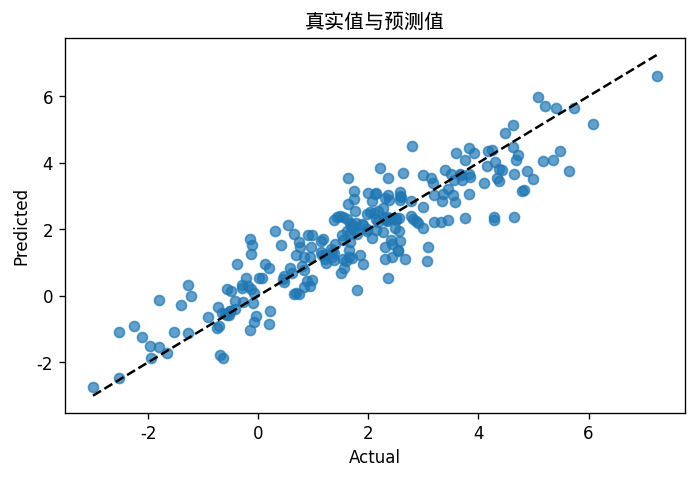

In [4]:
fig, ax = plot_actual_vs_pred(y, y_pred)
ax.set_title('真实值与预测值')
plt.tight_layout()
show(fig)
